## Exercise II: Monte Carlo Integration and Importance Sampling [Total: 15 Marks]

Consider the integral

\begin{equation}
    I = \int_0^1 \sin(\pi x(1-x))\mathrm{d}x = \mathbb{E}[X], \quad X=g(U), \quad g(U)=\sin(\pi U(1-U))
\end{equation}

where $U$ is a uniform random variable in $(0,1)$.



1.   Use Monte Carlo integration based on sampling $U$ to estimate $I$ with $1\sigma$ error at most $0.001$. How many samples do you need? (It is not necessary to automate this: trial and error is sufficient.) **[5 Marks]**
2.   Choose a random variable $Z$ on $(0,1)$ whose density resembles the integrand of $I$ and which you know how to sample efficiently (by inversion method, acceptance-rejection, or a built-in Python function). Estimate $I$ again using importance sampling, i.e. $I = \mathbb{E}[X']$ where $X' = g(Z) f_U(Z)/f_Z(Z)$, with an error of at most 0.001. How many samples did you need this time? Comment on the result. **[10 Marks]**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
the_seed = 123
rng = np.random.default_rng(seed=the_seed)


# 2.1

We generate independent samples from the $ \text{Uniform}(0,1)$ distribution and compute the estimator
$$
\hat{I}_N = \frac{1}{N} \sum_{i=1}^N \sin\big(\pi U_i (1-U_i)\big).
$$

The standard error of the estimator is given by
$$
\text{SE} = \frac{\hat{\sigma}}{\sqrt{N}},
$$
where $\hat{\sigma}^2$ is the sample variance.

We increase the number of samples $N$ until the estimated standard error is at most $0.001$.

 We need atlest 43000 observations for the 1 standard deviation to be below 0.001


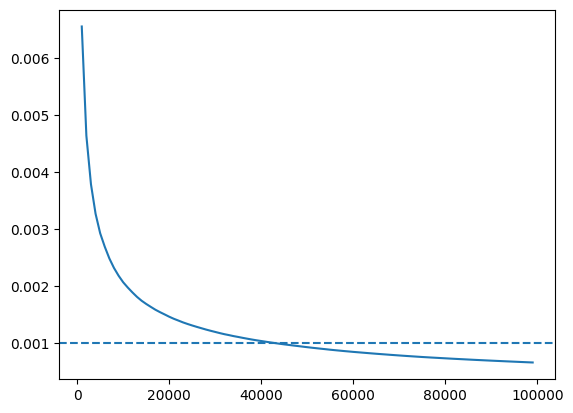

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
the_seed = 123
rng = np.random.default_rng(seed=the_seed)

N= 100_000
U = rng.uniform(size=(N,1))

def g_fct(sample):
    return np.sin(np.pi*sample*(1-sample))
trans = g_fct(U)
def MC_est(sample):
    return np.mean(sample,axis=0), np.std(sample, axis=0, ddof=1)/np.sqrt(len(sample))

step = int(N/100)
x_axis = list(range(step,N,step))
std_list = []
for i in x_axis:
    std_list.append(MC_est(trans[:i])[1])
plt.plot(x_axis, std_list)
plt.axhline(0.001, linestyle='--')
ind = np.where(np.array(std_list)<0.001)[0][0]
print(f' We need atlest {x_axis[ind]} observations for the 1 standard deviation to be below 0.001')


From the simulation, we observe that the standard error decreases as the number of samples $N$ increases, consistent with the theoretical rate
$$
\text{SE} \propto \frac{1}{\sqrt{N}}.
$$

From the plot, the standard error drops below the required threshold of $0.001$ at approximately
$$
N \approx 43{,}000.
$$

Thus, at least **43,000 samples** are required to achieve a $1\sigma$ error of at most $0.001$.

The curve shows a rapid decrease in error initially, followed by diminishing returns as $N$ becomes large. This behaviour is characteristic of Monte Carlo methods, where reducing error further requires disproportionately more samples.

# 2.2

Starting with something that looks like the integrand:

$$
f_{temp}(x)= \pi x(1-x)
$$

Valid PDFs integrate to 1,

$$
\int_0^1f_{temp}(x)dx =\frac{\pi}{6}
$$

So we normalize and take,

$$f_Z = \frac{6}{\pi}f_{temp}=6 x(1-x)$$

We are very lucky, because this is a standard known distriution (if you ask our ST429 teacher) $Z\sim Beta(2,2)$ which is symmetric and centred at $0.5$.

The integrand $\sin(\pi x(1-x))$ is symmetric and peaks near $x = 0.5$. To reduce variance, we choose a proposal distribution that concentrates more mass in this region.

The density is
$$
f_Z(z) = \frac{z^{\alpha-1}(1-z)^{\alpha-1}}{B(\alpha,\alpha)}.
$$

In [ ]:
def f_fct(X):
    return 6*X*(1-X)
# draw from beta-distribution now
X = rng.beta(2,2,size=N)
w = g_fct(X)/f_fct(X)
step = int(N/1000)
x_axis = list(range(step,N,step))
std_list_1 = []
std_list_2 = []
for i in x_axis:
    std_list_1.append(MC_est(trans[:i])[1])
    std_list_2.append(MC_est(w[:i])[1])

We rewrite the integral as
$$
I = \mathbb{E}[X'], \quad \text{where } X' = \frac{g(Z) f_U(Z)}{f_Z(Z)}.
$$

Since $f_U(z) = 1$ on $(0,1)$, this simplifies to
$$
X' = \frac{\sin(\pi Z(1-Z))}{f_Z(Z)}.
$$

The importance sampling estimator becomes
$$
\hat{I}_N^{IS} = \frac{1}{N} \sum_{i=1}^N \frac{\sin\big(\pi Z_i(1-Z_i)\big)}{f_Z(Z_i)}.
$$

 We need atlest 300 observations for the 1 standard deviation to be below 0.001


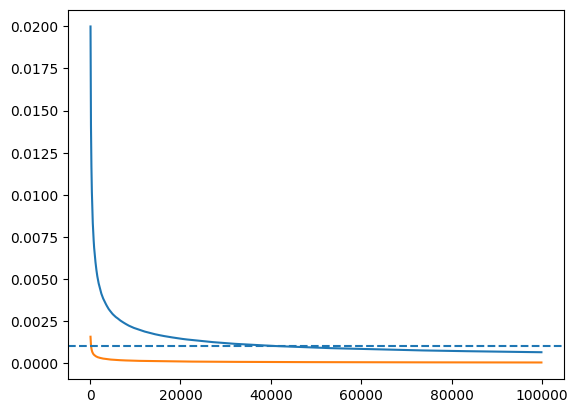

In [ ]:
plt.plot(x_axis, std_list_1)
plt.plot(x_axis, std_list_2)
plt.axhline(0.001, linestyle='--')
ind = np.where(np.array(std_list_2)<0.001)[0][0]
print(f' We need atlest {x_axis[ind]} observations for the 1 standard deviation to be below 0.001')


From the plot, we observe that the standard error decreases much more rapidly compared to standard Monte Carlo.

The required accuracy of $0.001$ is achieved at approximately
$$
N \approx 300.
$$

Thus, only **around 300 samples** are needed when using importance sampling, compared to approximately $43{,}000$ samples for standard Monte Carlo.

The estimated integral stabilises quickly, and the variance is significantly smaller across all sample sizes.

The improvement occurs because the proposal distribution
$$
f_Z(x) = 6x(1-x)
$$
closely matches the shape of the integrand, concentrating samples near $x = 0.5$, where $\sin(\pi x(1-x))$ is largest.

As a result, the variance of the estimator is greatly reduced, leading to much faster convergence.

In contrast, uniform sampling wastes many samples in regions where the integrand is small, making it inefficient.
